# 06 TAF's adjoint mode and the exact derivative: `global_ocean.cs32x15` with sea ice

- **Tier:** cluster (one CPU node; the run below used 8 cores)
- **Run time:** about 28 min (measured: 1638 s on a compute node pinned to 8 cores; two adjoint programs
  of about 13 min each, nearly all of it compiling)
- **Peak memory:** about 20 GB (measured: 18.1 GiB, while compiling)
- **Experiment:** `verification/global_ocean.cs32x15`, variant `input_ad.seaice_dynmix` (cubed sphere, 6 faces of
  32 x 32 in 12 tiles of 32 x 16, 15 levels, `pkg/seaice`, 5 steps; the control `xx_theta` and the cost of
  `data.ctrl` / `data.cost`)
- **Shows:** `exp.gradient(mode="run")`, which follows the adjoint-mode switch of `data.autodiff` as TAF's adjoint
  does, and `mode="exact"`, the derivative of the forward model; each one matches its own Fortran reference in
  `results/` (TAF's adjoint, TAF's tangent-linear model) to 10 digits or more and the other one only to 7-8. The
  sister run `input_ad.seaice` (approximate advection, MITgcm issue #1041) is described with our measurements at
  the end; it is not run here (time).

**Adjoint mode.** TAF's adjoint of MITgcm does not always differentiate the model that runs forward. Switches in
`data.autodiff` take effect only in the reverse sweep (`ADAUTODIFF_INADMODE_SET`): simpler or more robust
operators replace the forward ones there. TAF's tangent-linear model does not use them (`G_AUTODIFF_INADMODE_SET`
leaves `inAdMode = .FALSE.`). So where such a switch is set, TAF's adjoint and TAF's tangent-linear model compute
different derivatives. mitjax gives you both:

- `mode="run"` (the default) applies the run's switches as *backward-only* changes: the forward values are
  unchanged, the derivative follows TAF's adjoint mode. Compare it with `results/output_adm.*`.
- `mode="exact"` applies none: the derivative of the forward model. Compare it with `results/output_tlm.*`.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import time
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

import mitjax
from mitjax import paths

VERIFICATION = paths.UPSTREAM / "verification"


def new_out(name):
    """A new output directory runs/<name>-<n> next to this notebook (mitjax never writes into an existing one)."""
    n = 1
    while Path(f"runs/{name}-{n}").exists():
        n += 1
    return Path(f"runs/{name}-{n}")


def digits(a, b):
    """Agreeing significant digits of two numbers: floor(-log10(|a-b| / max(|a|,|b|))), 16 when equal."""
    if a == b:
        return 16
    return int(np.floor(-np.log10(abs(a - b) / max(abs(a), abs(b)))))


def ref_values(path, key):
    """The values of the lines holding `key` in a (possibly gzipped) MITgcm output file."""
    import gzip
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt") as fh:
        return [float(ln.split("=")[1]) for ln in fh if key in ln]

## The run and its switch

`input_ad.seaice_dynmix` sets one adjoint-mode switch:

In [2]:
VARIANT = "input_ad.seaice_dynmix"
ad = mitjax.load(VERIFICATION / "global_ocean.cs32x15", variant=VARIANT)
print((ad.exp_dir / VARIANT / "data.autodiff").read_text())
R = ad.results()
taf_adm = ref_values(R.output_adm, "ADM  adjoint_gradient")
taf_tlm = ref_values(R.output_tlm, "TLM  tangent-lin_grad")
print(f"TAF adjoint ({R.output_adm.name}):        ", taf_adm)
print(f"TAF tangent-linear ({R.output_tlm.name}):", taf_tlm)

# =========================
# pkg AUTODIFF parameters :
# =========================
#  inAdExact :: get an exact adjoint (no approximation) (def=.True.)
#  SEAICEuseFREEDRIFTswitchInAd :: switch on/off Free-Drift in AD mode (def=F)
#
 &AUTODIFF_PARM01
# inAdExact = .FALSE.,
  SEAICEuseFREEDRIFTswitchInAd = .TRUE.,
 &

TAF adjoint (output_adm.seaice_dynmix.txt):         [4.33606569062825, 4.12973208555242, 3.37114436227497, 3.00174853054541]
TAF tangent-linear (output_tlm.seaice_dynmix.txt.gz): [4.33606570251172, 4.12973210548431, 3.37114438864709, 3.00174856274997]


`SEAICEuseFREEDRIFTswitchInAd = .TRUE.`: the forward solves the sea-ice momentum equations with the iterative
line solver `SEAICE_LSR`; in the reverse sweep TAF switches to the free-drift solution instead
(`autodiff_inadmode_set_ad.F:71-74` sets `SEAICEuseFREEDRIFT`, and `seaice_dynsolver.F:308-321` then takes the ice
velocity from `SEAICE_FREEDRIFT`, without internal ice stress). The adjoint of the iterative solver is avoided.

mitjax's `mode="run"` does the same backward-only: the forward still runs the LSR, and the derivative of the ice
velocity is the derivative of the free drift. `mode="exact"` differentiates the LSR iterations that were
executed. This build does not tell TAF to record those iterations (`SEAICE_LSR_ADJOINT_ITER` is not defined);
the API differentiates the executed sweeps anyway, as it does in notebook 05 where the build sets it (plan
decisions 14 and 17: TAF's adjoint of the unrecorded solver is wrong by construction). That is the default,
`lsr_derivative=None`, so the calls below pass no argument for it; `lsr_derivative="sweeps"` would select the same
program, `"run"` the build's own choice (no derivative of the solver: the gradient stops with an error). In
`mode="run"` the free drift replaces the solver's derivative anyway.

## `mode="run"` and `mode="exact"`

Two separate programs (the switches are part of the compiled program); each takes about 13 minutes here, nearly
all of it compiling.

In [3]:
grads = {}
for mode in ("run", "exact"):
    t0 = time.time()
    grads[mode] = ad.gradient(out=new_out(f"06_{mode}"), mode=mode)
    print(f"mode={mode!r}: {time.time() - t0:.0f} s, fc = {grads[mode].fc:.15E}")
    jax.clear_caches()

mode='run': 776 s, fc = 1.108458597725937E+05


mode='exact': 823 s, fc = 1.108458597725937E+05


The gradient check points of `data.grdchk` (`xx_theta`, the first four points of tile 1 at level 1), located as
`pkg/grdchk` locates them. This uses `mitjax/drivers/grdchk.py`, below the API (`ad.grdchk` would also compute the
finite differences, eight more cost evaluations):

In [4]:
from mitjax.drivers.grdchk import control_by_name, grdchk_positions, grdchk_settings, storage_point

m = ad.model(new_out("06_points"))
settings = grdchk_settings(m.exp)
ctl = control_by_name(m, settings["grdchkvarname"])
points = [storage_point(ctl, r, m.cfg.size) for _, r in grdchk_positions(m, ctl, settings)]
g = {k: [float(grads[k].adxx[1][p]) for p in points] for k in grads}
d = {(k, ref): [digits(a, b) for a, b in zip(g[k], vals)] for k in g
     for ref, vals in (("adm", taf_adm), ("tlm", taf_tlm))}
print("      mode='run'               mode='exact'            digits vs TAF adjoint   digits vs TAF tangent-linear")
for n in range(len(points)):
    print(f"  {g['run'][n]:22.14E}  {g['exact'][n]:22.14E}     run {d['run', 'adm'][n]:2d}  exact {d['exact', 'adm'][n]:2d}"
          f"         run {d['run', 'tlm'][n]:2d}  exact {d['exact', 'tlm'][n]:2d}")
print("TAF adjoint / TAF tangent-linear - 1:", ", ".join(f"{a / b - 1:.1E}" for a, b in zip(taf_adm, taf_tlm)))

      mode='run'               mode='exact'            digits vs TAF adjoint   digits vs TAF tangent-linear
    4.33606569062699E+00    4.33606570254974E+00     run 12  exact  8         run  8  exact 11
    4.12973208555705E+00    4.12973210559580E+00     run 11  exact  8         run  8  exact 10
    3.37114436227557E+00    3.37114438874647E+00     run 12  exact  8         run  8  exact 10
    3.00174853054879E+00    3.00174856287007E+00     run 11  exact  7         run  7  exact 10
TAF adjoint / TAF tangent-linear - 1: -2.7E-09, -4.8E-09, -7.8E-09, -1.1E-08


In [5]:
MIN_DIGITS = 10                                    # testreport's MATCH_CRIT
assert grads["run"].fc == grads["exact"].fc       # backward-only: the forward and the cost are the same
assert all(np.isfinite(grads[k].adxx[1]).all() for k in grads)
assert min(d["run", "adm"]) >= MIN_DIGITS and min(d["exact", "tlm"]) >= MIN_DIGITS, d
assert max(d["run", "tlm"]) < MIN_DIGITS and max(d["exact", "adm"]) < MIN_DIGITS, d     # the switch is visible

`mode="run"` reproduces TAF's adjoint, `mode="exact"` TAF's tangent-linear model, each to 10-12 digits; across
(run against the tangent-linear model, exact against TAF's adjoint) they agree to 7-8 digits only, as TAF's two
results do with each other. At these four points the ice dynamics matters little (the switch changes the gradient
by about 1e-8); elsewhere it does more:

## Where the switch acts

The difference of the two gradients at level 1, on the six faces of the cube. With the optional plotting package
`nereus` installed it is drawn on a map; without it, face by face with matplotlib (each face is two tiles of 32 x 16; the faces are shown side by side, not folded into a cube).

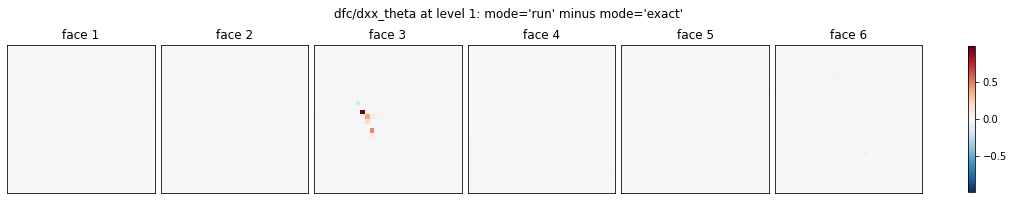

max |run - exact| = 9.80E-01; max |exact| = 3.21E+01


In [6]:
sz = m.cfg.size
OL = (slice(None), 0, slice(sz.OLy, sz.OLy + sz.sNy), slice(sz.OLx, sz.OLx + sz.sNx))
g_run, g_exact = grads["run"].adxx[1][OL], grads["exact"].adxx[1][OL]       # [tile, j, i], level 1
diff = g_run - g_exact
vmax = np.abs(diff).max()

try:
    import nereus                                  # optional (pip install nereus: needs cartopy, xarray, ...)
except ImportError:
    nereus = None

if nereus is not None:
    grid = ad.grid()                               # GRID.h arrays by Fortran name
    xC, yC = grid.interior("xC"), grid.interior("yC")    # cell-centre longitude and latitude, [tile, j, i]
    fig, ax, _ = nereus.plot(diff.ravel(), xC.ravel(), yC.ravel(), cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                             title="dfc/dxx_theta at level 1: run minus exact", figsize=(9, 4.5))
else:
    faces = [np.concatenate([diff[2 * f], diff[2 * f + 1]], axis=0) for f in range(6)]  # tiles 2f+1, 2f+2
    fig, axs = plt.subplots(1, 6, figsize=(14, 2.9), dpi=72, constrained_layout=True)
    for f, a in enumerate(axs):
        pc = a.pcolormesh(faces[f], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        a.set_title(f"face {f + 1}"); a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
    fig.colorbar(pc, ax=axs, shrink=0.8)
    fig.suptitle("dfc/dxx_theta at level 1: mode='run' minus mode='exact'")
plt.show()
print(f"max |run - exact| = {vmax:.2E}; max |exact| = {np.abs(g_exact).max():.2E}")

## One switch at a time, and the tangent-linear model: below the API

`mode` turns all of a run's switches on or off together, and the API computes adjoints only. To toggle one switch,
or to run mitjax's own tangent-linear model, go one level down, to the drivers the API wraps:
`mitjax/drivers/ad_switches.py` turns the run's `data.autodiff` into backward-only options of the model's arrays,
`mitjax/ad/modes.py` holds the CG2D and LSR derivative options, and `mitjax/drivers/adjoint_run.py` runs the
adjoint (`value_and_grad`) and the tangent-linear model (`jvp`, as in notebook 03's dot test). These interfaces are
less stable than the API's. For example, on `input_ad.seaice` (next section) the approximate advection in the
reverse sweep for the ocean's tracers only, with the sea ice's advection differentiated exactly (the hooks
`with_run_switches` sets, one of them by hand, and without its checks):

```python
from mitjax.ad import approx_advection as AA
from mitjax.ad.modes import with_lsr_derivative
from mitjax.drivers import adjoint_run
m = mitjax.load(VERIFICATION / "global_ocean.cs32x15", variant="input_ad.seaice").model("runs/one_switch")
drv = adjoint_run.GenarrAdjoint(m, key=control_by_name(m, "xx_theta").key)
sp = with_lsr_derivative(drv.model.pkc["sp"], "sweeps")                 # A1, the API's default here
model = drv.model.replace(params=drv.model.params.replace(static={AA.OPTION: "routine"}),   # GAD_ADVECTION
                          pkc={**drv.model.pkc, "sp": sp})              # sea-ice advection: not switched
fc, grad = drv.value_and_grad(model=model)
```

It is not run here (one more program, about 15 minutes).

**TAF's tangent-linear model through the API.** One difference between TAF's two derivatives is not an
adjoint-mode switch: on a nonlinear free surface the CG2D operator depends on the state, and TAF's tangent-linear
model (like TAF's adjoint with `cg2dFullAdjoint = .FALSE.`) keeps it passive, while `mode="exact"` differentiates
it. `ad.gradient(out, mode="exact", cg2d_derivative="run")` treats the operator as the run's `cg2dFullAdjoint`
says and applies no switch: that is how a user gets TAF's tangent-linear treatment of CG2D. In this notebook's run
it changes nothing (see the end); for `input_ad.seaice` it is the last row of the table below.

## Not run here: `input_ad.seaice` and MITgcm issue #1041

`input_ad.seaice` (2 steps) sets `useApproxAdvectionInAdMode = .TRUE.` instead: in the reverse sweep the
advection of temperature, salinity and sea ice uses scheme 30 (third-order DST without flux limiter) instead of
the forward's scheme 33 (with the limiter; `gad_advection.F:194-202`, `seaice_advection.F:177-183`). Two more
things matter there. Its build lacks `SEAICE_LSR_ADJOINT_ITER`, so TAF's adjoint of `SEAICE_LSR` is approximate
(`seaice_lsr.F:804-807`: "the adjoint is necessarily wrong"). And it runs a nonlinear free surface
(`nonlinFreeSurf = 4`, r*), where the CG2D operator depends on the state: TAF's adjoint (`cg2dFullAdjoint =
.FALSE.`) and TAF's tangent-linear model keep the operator passive, while `mode="exact"` differentiates it.

We ran the calls of this notebook on it (same node, 8 cores; three programs, 45 min), with digits at the four
check points:

| gradient of `input_ad.seaice` | vs TAF's adjoint | vs TAF's tangent-linear model |
|---|---|---|
| `mode="run"` (approximate advection in the reverse sweep) | 8, 7, 7, 7 | 2, 3, 3, 3 |
| `mode="exact"` (CG2D operator active) | 2, 3, 3, 3 | 7, 7, 7, 8 |
| `mode="exact", cg2d_derivative="run"` (no switch, CG2D passive as in TAF) | 2, 3, 3, 3 | 11, 11, 12, 11 |

- TAF's adjoint and TAF's tangent-linear model of this run differ by 3e-4 to 1.2e-3. The approximate advection
  explains that gap up to about 1e-8: with it in the reverse sweep, mitjax reaches TAF's adjoint to 7-8 digits.
- The remaining 1e-8 is TAF's approximate adjoint of the sea-ice solver, which no backward-only switch can follow
  (mitjax differentiates the executed sweeps). We reported it to the MITgcm developers, together with the
  `lab_sea` case of notebook 05, as [MITgcm issue #1041](https://github.com/MITgcm/MITgcm/issues/1041).
- `mode="exact"` is the derivative of the forward model including the free-surface operator; TAF's tangent-linear
  model leaves the operator out, which here changes the gradient by about 1e-8. Without any switch and with CG2D
  as the run treats it (`cg2d_derivative="run"`), mitjax matches TAF's tangent-linear model to 11-12 digits. (We
  measured that row with the drivers, before the API had the argument; the API call builds the same program.)

In the run of this notebook (`input_ad.seaice_dynmix`, `nonlinFreeSurf = 2`) the CG2D operator is not updated
during the run (`forward_step.F:865-871`), so `mode="exact"` and TAF's tangent-linear model differentiate the same
thing (measured: the no-switch program with CG2D as the run's gives the same gradient as `mode="exact"`, bit for
bit).